# The Capstan Drive

**A parametric model, and the first subject of a standardized drive-comparison bench.**

This notebook does two things at once.

The first is a study of the cable capstan drive from first principles: ratio, stiffness,
torque capacity, stroke, drag and efficiency all derived from the cable, the two radii
and the pretension — not read off a datasheet.

The second is to serve as the first subject of a bench that will later carry harmonic
and cycloidal drives on exactly the same tests, the same arm, and the same controller.

---

## What a simulation like this can and cannot tell you

Worth being blunt about this before any plots appear, because it governs how much
weight the conclusions can carry.

**The trap is circularity.** If you assign each drive an efficiency, a backlash and a
stiffness from the literature and then "discover" that the capstan backdrives better,
you have discovered nothing — you have replayed your own inputs with axes on them.
Three things keep this bench honest:

1. **Parameters are derived where they can be.** For the capstan, nearly everything
   follows from geometry and material. That makes its results predictions rather than
   assumptions. Every drive carries a `physics_derived` flag so the provenance of a
   number is never ambiguous.

2. **Coupled quantities stay coupled.** Forward and backward efficiency are not two
   independent knobs. Under a loss model where dissipation is proportional to
   transmitted torque, they are locked together as
   $\eta_b = 2 - 1/\eta_f$ — the same relation that governs lead screws. So
   $\eta_f = 0.75 \Rightarrow \eta_b = 0.67$, and $\eta_f = 0.5$ is *exactly* the
   self-locking boundary. Backdrivability is an output of the model, not an input.

3. **The interesting results are emergent.** Reflected inertia, resonance placement,
   peak torque on impact, and where design curves *cross* are not things you can read
   off a spec sheet, and they are where the value is.

**What it cannot tell you:** anything about fatigue life, thermal behaviour, assembly
tolerance, cost, or manufacturability. It is a rigid-body-plus-one-compliance model of a
single joint. It will not predict when your cable breaks.

## 1. Every transmission is the same kind of object

The bench rests on one idea: whatever is inside it, a transmission is a **two-port
element** between a motor and a load, and it is completely described by five behaviours.

| | quantity | where drives differ |
|---|---|---|
| 1 | ratio + kinematic error $\;\theta_{out} = \theta_m/N + e(\theta_m)$ | harmonic: 2 cycles/input rev · cycloidal: lobe frequency · capstan: ~0 |
| 2 | compliance $\;K(\delta)$ | capstan: cable $EA$ · harmonic: flexspline windup |
| 3 | loss $\;\tau_{loss}(\tau_j,\omega)$ | the asymmetry here *is* backdrivability |
| 4 | reflected inertia $\;N^2 J_m$ | dominates impact behaviour |
| 5 | limits $\;\tau_{max}$, stroke, slip | a capstan slips; gears do not |

Which gives one set of equations for every drive, written output-referred so the ratio
never appears explicitly:

$$J_{refl}\,\dot\omega_m = N\tau_m - \tau_j - \tau_{loss}
\qquad
J_l\,\dot\omega_l = \tau_j - mgL\cos\theta_l + \tau_{ext}$$

$$\tau_j = K\delta + C\dot\delta,
\qquad \delta = \theta_m + e(\theta_m) - \theta_l - \theta_{slip}$$

Non-dimensionalizing on the **plant** — $\tau^* = mgL$, $t^* = \sqrt{J_l/mgL}$ — collapses
this to six numbers:

$$\Pi_J = \frac{N^2 J_m}{J_l}, \quad
\Omega_n = \sqrt{\frac{K_{out}}{mgL}}, \quad
\zeta_d, \quad \eta_f, \quad \hat\tau_{max}, \quad e(\cdot)$$

Two drives landing on the same six numbers are indistinguishable to the load. Scales are
taken from the plant and never from the drive — that is what makes the comparison fair.

In [1]:
import sys, os, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

from drivelab import Config, simulate, viz
from drivelab.drives import CapstanDrive
from drivelab.catalog import MOTORS, CABLES, ARMS
from drivelab.catalog.configs import (reference_capstan, harmonic_like,
                                      cycloidal_like, ideal_reference)
from drivelab.bench import run_suite, summary_row, resonance_pair

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
plt.rcParams["figure.dpi"] = 110
print("ready")

ready


## 2. The two closed forms worth knowing

### Torque capacity

The cable grips while the Euler–Eytelwein condition holds,
$T_{tight}/T_{slack} \le e^{\mu\beta}$. With a symmetric pretension,
$T_{tight} = T_p + \Delta T$ and $T_{slack} = T_p - \Delta T$, and the transmitted torque
is $\tau = 2\,\Delta T\, r_c$. Solving for the largest $\Delta T$ that still grips:

$$\boxed{\;\tau_{max} = 2\,T_p\,r_c \tanh\!\left(\frac{\mu\beta}{2}\right)\;}$$

The $\tanh$ saturates hard, and that has a direct design consequence: **wraps are nearly
free and nearly useless past about three.** The only real levers are pretension and
radius — and pretension is paid for twice, in bearing load and in drag.

### Stiffness

Two cable runs of stiffness $EA/L$ acting at radius $R$:

$$\boxed{\;K_{out} = 2\frac{EA}{L}R^2 \qquad K_{in} = \frac{K_{out}}{N^2} = 2\frac{EA}{L}r_c^2\;}$$

This is the one that catches people. Output stiffness grows with $R^2$, but
**input-referred stiffness falls with $r_c^2$**. Raising the ratio by shrinking the
capstan guts the stiffness the *motor* sees, quadratically, even as the number quoted on
the output side improves. Since the motor is what closes the loop, that is what limits
control bandwidth.

A caution on $E$: a wire rope is not a solid bar. The strands bed in before the metal
carries, so 7×19 steel runs near 100–130 GPa against 200 GPa bulk. Using the bulk figure
overstates drive stiffness by roughly 2×.

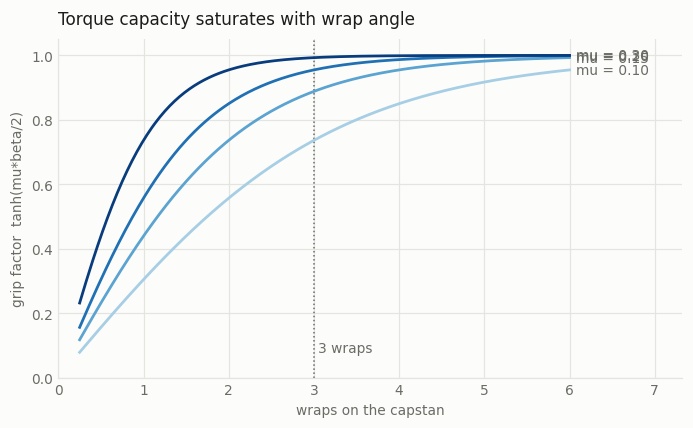

,wraps,grip factor,tau_max [N*m],gain over 3 wraps
0,1,0.5569,2.339,-41.7%
1,2,0.8501,3.571,-11.0%
2,3,0.9549,4.011,+0.0%
3,4,0.9870,4.145,+3.4%
4,6,0.9989,4.196,+4.6%
5,10,1.0000,4.200,+4.7%


In [2]:
viz.plot_wrap_saturation()
plt.tight_layout(); plt.show()

# The saturation, as numbers.
rows = []
for n in (1, 2, 3, 4, 6, 10):
    d = CapstanDrive(r_capstan=0.010, R_output=0.080, cable=CABLES["steel-7x19"],
                     cable_diameter=0.001, n_wraps=n, mu=0.2, pretension=200.0)
    rows.append({"wraps": n, "grip factor": d.grip_factor,
                 "tau_max [N*m]": d.tau_max_slip()})
df = pd.DataFrame(rows)
df["gain over 3 wraps"] = df["tau_max [N*m]"] / df["tau_max [N*m]"].iloc[2] - 1
df.style.format({"grip factor": "{:.4f}", "tau_max [N*m]": "{:.3f}",
                 "gain over 3 wraps": "{:+.1%}"})

## 3. The design conflict this model exists to expose

Three quantities pull against each other, and no single one of them is the problem:

- **torque** wants a small capstan (high $N$) and high pretension
- **high pretension** wants a thick cable
- **a thick cable** wants a *large* capstan, to keep the bend ratio $D/d$ healthy

Bend ratio does not limit torque — it limits *life*. Run a cable around too tight a
sheave and it works fine, then fails early. So it is the constraint that is easiest to
design straight past, and the one most likely to bite.

`CapstanDrive.sized_for` does the sizing the way you would on paper: invert the torque
equation for the pretension you need, then pick the smallest cable whose tight side still
clears the allowable stress. Sweeping $N$ through that procedure shows where the design
space actually closes.

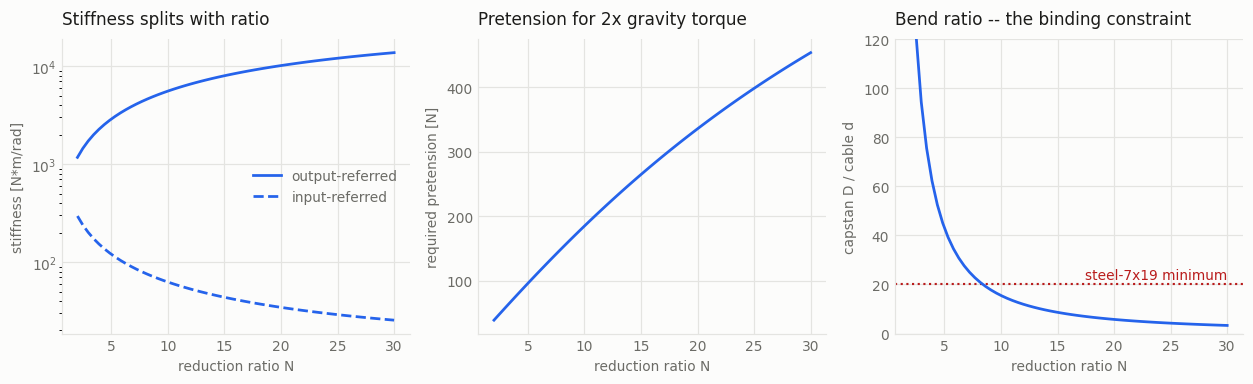

In [3]:
viz.plot_ratio_tradeoff(R_output=0.090)
plt.tight_layout(); plt.show()

Read the right-hand panel carefully — it is the headline result of this section.

For a 300 mm arm carrying 0.5 kg, with a 90 mm output sector and steel 7×19, the bend
ratio drops below the cable's minimum at **N ≈ 8**. Everything above that ratio is a
design that will work on the bench and fail in the field.

That is why real capstan drives are physically larger than their torque rating suggests,
and why the high-ratio ones are two-stage. The escape routes are all visible in the
three panels: a bigger sector, a lower ratio per stage, or a cable that tolerates tight
bends (UHMWPE will, at the cost of creep — and creep in a capstan is pretension loss,
which is torque capacity loss).

In [4]:
# What the three escape routes actually buy.
arm = ARMS["desktop-300"]
options = [
    ("steel, R=90mm, N=8",    dict(R_output=0.090, N=8.0,  cable="steel-7x19")),
    ("steel, R=90mm, N=14",   dict(R_output=0.090, N=14.0, cable="steel-7x19")),
    ("steel, R=140mm, N=14",  dict(R_output=0.140, N=14.0, cable="steel-7x19")),
    ("UHMWPE, R=90mm, N=14",  dict(R_output=0.090, N=14.0, cable="uhmwpe-sk78")),
]
rows = []
for label, kw in options:
    c = reference_capstan(**kw)
    d = c.drive
    rows.append({
        "design": label,
        "N": d.N,
        "cable d [mm]": d.d * 1e3,
        "pretension [N]": d.T_p,
        "tau_max [N*m]": d.tau_max(),
        "D/d": d.bend_ratio,
        "bend ok": d.bend_ratio_ok(),
        "K_out [N*m/rad]": d.stiffness_out(0.0),
        "K_in [N*m/rad]": d.stiffness_out(0.0) / d.N ** 2,
        "stroke [deg]": math.degrees(d.stroke_limit()),
        "issues": "; ".join(c.feasibility()) or "ok",
    })
pd.DataFrame(rows).set_index("design")

,N,cable d [mm],pretension [N],tau_max [N*m],D/d,bend ok,K_out [N*m/rad],K_in [N*m/rad],stroke [deg],issues
design,,,,,,,,,,
"steel, R=90mm, N=8",7.688984,1.046177,150.469148,3.383294,21.506879,True,4539.461524,76.783239,397.971957,ok
"steel, R=90mm, N=14",12.767214,1.346972,249.432868,3.383294,9.545217,False,7550.111090,46.319205,239.676417,capstan D/d = 10 is below the cable minimum 20
"steel, R=140mm, N=14",13.319340,1.105026,167.873434,3.383294,18.099123,False,7848.958199,44.243205,229.741105,capstan D/d = 18 is below the cable minimum 20
"UHMWPE, R=90mm, N=14",12.991942,1.080788,254.196501,3.383294,11.896085,True,3258.948848,19.307649,235.530606,ok


## 4. The reference capstan

Everything from here on uses one specific, inspectable configuration so that "the
capstan result" means a definite thing. Note `limiting_mode`: the sizing routine
balances slip against cable strength, so both limits arrive together by construction.

Note also `eta_at_10pct` against `eta_at_tau_max`. The capstan's dominant loss is
**preload-driven and load-independent** — cable bending hysteresis over the capstan,
$\tau_{c0} = N\,\mu_{bend}\,d\,T_p$. That is a very different shape from a gearbox, whose
loss is mostly proportional to load. It means capstan efficiency *climbs* with load
rather than staying flat, and it is the reason the drive stays backdrivable when loaded.

In [5]:
cfg = reference_capstan()
s = cfg.drive.summary()
for k in ["N", "cable", "n_wraps", "pretension_N", "pretension_pct_break",
          "grip_factor", "tau_max", "tau_max_slip", "tau_max_strength",
          "limiting_mode", "bend_ratio", "bend_ratio_ok", "K_out", "K_in",
          "stroke_limit_deg", "no_load_drag", "eta_at_10pct", "eta_at_tau_max"]:
    v = s[k]
    print("  %-22s %s" % (k, ("%.5g" % v) if isinstance(v, float) else v))

print("\n  -- as the load sees it --")
for k, v in sorted(cfg.pi.as_dict().items()):
    print("  %-22s %s" % (k, ("%.5g" % v) if isinstance(v, float) else v))
print("\n  feasibility:", cfg.feasibility() or "ok")

  N                      7.689
  cable                  steel-7x19 d=1.05mm
  n_wraps                3
  pretension_N           150.47
  pretension_pct_break   17.051
  grip_factor            0.95493
  tau_max                3.3833
  tau_max_slip           3.3833
  tau_max_strength       3.3833
  limiting_mode          slip
  bend_ratio             21.507
  bend_ratio_ok          True
  K_out                  4539.5
  K_in                   76.783
  stroke_limit_deg       397.97
  no_load_drag           0.024208
  eta_at_10pct           0.92015
  eta_at_tau_max         0.97811

  -- as the load sees it --
  Omega_n                51.802
  Pi_J                   0.17875
  err_amp_arcmin         0
  eta_b                  0.98477
  eta_f                  0.985
  f_resonance_ratio      133.03
  self_locking           False
  tau_max_hat            2
  zeta_d                 0.02

  feasibility: ok


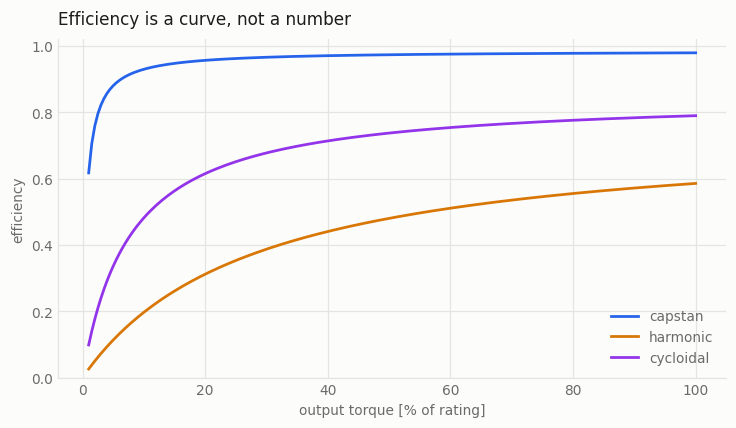

In [6]:
# Efficiency is a curve, not a number -- and the shapes differ by mechanism.
viz.plot_efficiency_curves(
    {"capstan": cfg.drive,
     "harmonic": harmonic_like().drive,
     "cycloidal": cycloidal_like().drive},
    tau_max=4.0)
plt.tight_layout(); plt.show()

## 5. Watching it move

The animation below drives the reference capstan through the lost-motion test. Windup is
drawn **exaggerated** — a real capstan deflects by arcminutes, which is invisible at this
scale — and the exaggeration factor is printed on the figure so the picture cannot be
mistaken for a measurement. If the cable ever exceeds its grip limit, the panel says
`SLIPPING`.

In [7]:
from IPython.display import HTML
from drivelab.bench.tests import t1_lost_motion

r_anim = t1_lost_motion(cfg)
HTML(viz.animate_capstan(r_anim, stride=20, dpi=72).to_jshtml())

## 6. The standardized tests

Five tests, identical for every drive, times expressed in units of the plant time scale
so the same test is the same test at any scale.

| | test | what it isolates |
|---|---|---|
| **T1** | lost motion | input locked, output pushed slowly back and forth |
| **T2** | cyclic tracking | PD control, *fixed* bandwidth rule for all drives |
| **T3** | backdrive | torque ramp at the output, motor unpowered |
| **T4** | impact | swing into a virtual wall |
| **T5** | frequency | chirp, FRF from motor torque to link angle |

Two deliberate choices are worth flagging, because both are places where a comparison
usually goes quietly wrong:

**The controller is fixed, not tuned per drive.** Same `alpha` for everyone. A drive that
cannot support the bandwidth rings or goes unstable — and that *is* the finding. Tuning
each drive to its own limit would hide exactly the difference being measured.

**The wall in T4 is referenced to the plant, not the drive.** $k_{wall} = \Omega^2 mgL$,
so every drive hits the identical obstacle. Scaling the wall by each drive's own
stiffness would mean the stiff drive gets tested against a stiffer wall, and the result
would partly be measuring the test rig.

In [8]:
%time results = run_suite(cfg, verbose=True)

  T1   ok


  T2   ok
  T3   ok
  T3s  ok


  T4   ok


  T5   ok
Wall time: 55.1 s


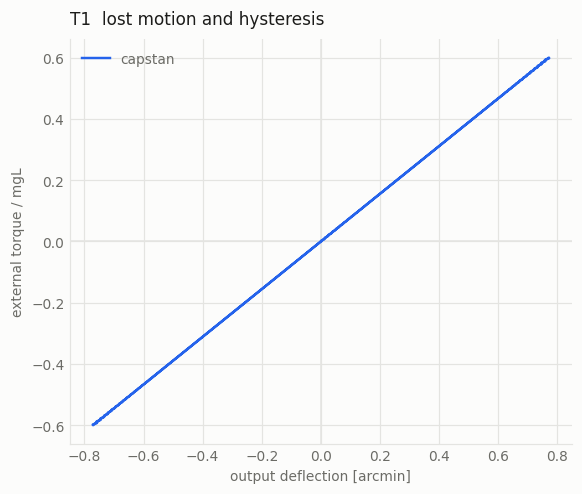

  lost motion       0.0002 arcmin   (a capstan has no backlash; this is presliding)
  measured K        4527.0 N*m/rad   vs 4539.5 derived from EA/L  (0.28% error)
  loss per cycle    1.01e-07 J


In [9]:
viz.plot_hysteresis({"capstan": results["T1"][0]})
plt.tight_layout(); plt.show()

m = results["T1"][1]
print("  lost motion       %.4f arcmin   (a capstan has no backlash; this is presliding)"
      % m["lost_motion_arcmin"])
print("  measured K        %.1f N*m/rad   vs %.1f derived from EA/L  (%.2f%% error)"
      % (m["stiffness_Nm_rad"], cfg.drive.stiffness_out(0.0),
         100 * abs(m["stiffness_Nm_rad"] / cfg.drive.stiffness_out(0.0) - 1)))
print("  loss per cycle    %.3g J" % m["hysteresis_loss_J"])

That the measured stiffness recovers the analytic $2(EA/L)R^2$ to within a fraction of a
percent is a check on the bench, not a result about the capstan — but it is the kind of
check worth keeping visible.

The loop itself is the interesting part. With the LuGre bristle model the reversal traces
a rounded *presliding* curve rather than a sharp corner, which is what a real drive does
and what makes the enclosed area a meaningful dissipation figure.

In [10]:
from drivelab.bench.tests import t3_backdrive
from drivelab.bench.metrics import t3_metrics

bd = {"open circuit": results["T3"][1], "phases shorted": results["T3s"][1]}
for k, m in bd.items():
    print("  %-16s breakaway %.4f N*m  =  %.3f x mgL  =  %.1f%% of rating"
          % (k, m["backdrive_torque_Nm"], m["backdrive_torque_hat"],
             m["backdrive_pct_rated"]))
print("\n  short-circuit damping kt^2/R = %.4f N*m/(rad/s) at the rotor"
      % cfg.motor.short_circuit_damping)

  open circuit     breakaway 0.5585 N*m  =  0.330 x mgL  =  16.5% of rating
  phases shorted   breakaway 0.6982 N*m  =  0.413 x mgL  =  20.6% of rating

  short-circuit damping kt^2/R = 0.0233 N*m/(rad/s) at the rotor


Both numbers matter, and quoting only the first is how backdrivability claims get
overstated. The mechanism backdrives beautifully; the *motor* does not necessarily. For a
low-ratio drive the $k_t^2/R$ term is frequently the dominant resistance — a capstan that
feels free with the phases open can feel notably stiffer with them connected.

In [11]:
from drivelab.bench.tests import t4_impact
from drivelab.bench.metrics import t4_metrics

m4 = results["T4"][1]
print("  peak transmitted      %.2f N*m  =  %.2f x mgL" %
      (m4["peak_transmitted_Nm"], m4["peak_transmitted_hat"]))
print("  as a fraction of the drive rating:  %.2f" % m4["peak_over_rating"])
print("  momentum from the motor:            %.1f%%" %
      (100 * m4["reflected_momentum_share"]))
print("  did the cable slip?                 %s  (%.1f arcmin of lost registration)"
      % (m4["slipped"], m4["slip_arcmin"]))

  peak transmitted      3.38 N*m  =  2.00 x mgL
  as a fraction of the drive rating:  1.00
  momentum from the motor:            15.2%
  did the cable slip?                 True  (445.6 arcmin of lost registration)


This is the result that most repays attention.

The capstan's peak transmitted torque sits at **exactly its rating** — because the cable
slipped. A capstan is a *mechanical fuse*: it cannot transmit more than
$2T_p r_c \tanh(\mu\beta/2)$ no matter how hard it is hit, so an impact that would
destroy a geared drive is absorbed as slip.

The cost is real and appears in the same output: the drive loses registration
permanently. An encoder on the motor no longer knows where the output is. Whether that
trade is worth taking is an application question — but it is a genuine, structural
difference in kind between a friction coupling and a toothed one, and no efficiency
figure captures it.

## 7. Against the other two

Provenance matters here, and the table reports it. The capstan row is **derived** from
geometry. The harmonic and cycloidal rows are `GenericGearedDrive` containers holding
class-typical *published* figures — legitimate bench subjects, but they tell you what
those drives do, not why.

One thing they are not allowed to fake: efficiency in both directions is locked together
through the loss model, so $\eta_b$ follows from $\eta_f$ rather than being a second free
knob.

In [12]:
configs = {
    "capstan": reference_capstan(),
    "harmonic": harmonic_like(),
    "cycloidal": cycloidal_like(),
}
rows = []
for name, c in configs.items():
    print("running %s ..." % name)
    rows.append(summary_row(c, run_suite(c)))
table = pd.DataFrame(rows).set_index("config").T
table

running capstan ...


running harmonic ...


running cycloidal ...


config,capstan 7.7:1 on desktop-300,harmonic-100 (datasheet),cycloidal-30 (datasheet)
derived,True,False,False
N,7.688984,100.0,30.0
Pi_J,0.178749,24.242828,2.182424
Omega_n,51.80209,64.327124,108.732684
eta_f,0.985,0.75,0.85
eta_b,0.984772,0.666667,0.823529
T1.lost_motion_arcmin,0.000156,0.000166,1.499892
T1.stiffness_hat,2676.069685,4136.351023,3056.062956
T1.hysteresis_loss_hat,0.0,0.0,0.000024
T2.rms_error_arcmin,45.505422,627.904774,70.260587


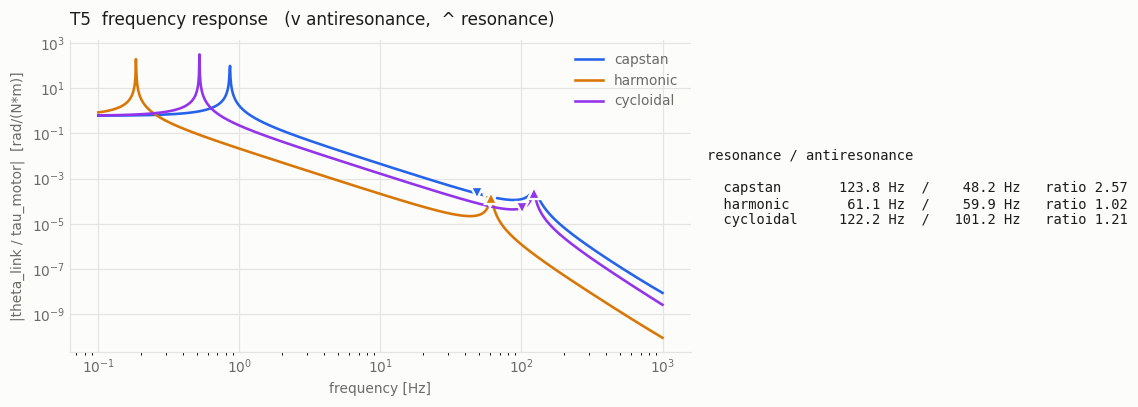

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8),
                         gridspec_kw={"width_ratios": [1.6, 1]},
                         facecolor=viz.SURFACE)
viz.plot_bode(configs, ax=axes[0])
axes[1].axis("off")
sep = {k: resonance_pair(c) for k, c in configs.items()}
txt = "resonance / antiresonance\n\n"
for k, (fa, fr) in sep.items():
    txt += "  %-11s  %6.1f Hz  /  %6.1f Hz   ratio %.2f\n" % (k, fr, fa, fr / fa)
axes[1].text(0, 0.5, txt, family="monospace", fontsize=9,
             color=viz.INK, va="center")
plt.tight_layout(); plt.show()

## 8. What the bench actually found

Reading across the table and the figures, four results stand out. All four are
*consequences* of the models rather than inputs to them.

**1. Reflected inertia is the dominant difference, and it is not close.**
$\Pi_J = N^2 J_m / J_l$ comes out at **0.18 for the capstan against 24 for the 100:1
harmonic** — a factor of ~130 on the same arm with the same motor. The capstan's rotor
contributes 15% of the momentum arriving at an impact; the harmonic's contributes 96%.
Peak transmitted torque on impact differs by two orders of magnitude. Nothing on a
datasheet says this, and it follows entirely from $N^2$.

**2. Backdrivability is predicted, not assumed.** $\eta_f = 0.985$ derived from cable
bending hysteresis gives $\eta_b = 0.985$; the harmonic's published 0.75 gives 0.67. The
measured breakaway torques follow. And the shape of the efficiency curve differs in kind:
preload-dominated (capstan, climbs steeply with load) versus load-proportional (gears,
flat).

**3. The harmonic's resonance and antiresonance nearly coincide** — a separation ratio of
about 1.02 against the capstan's 2.57. With $\Pi_J \gg 1$ the two features collapse onto
each other and the usable control-bandwidth window closes. This is a direct consequence
of reflected inertia and it is invisible in any static specification.

**4. The capstan's binding constraint is geometric, not tribological.** It is not
efficiency or torque density that limits a compact single-stage capstan — it is cable
bend ratio, which caps useful $N$ near 8 for steel on a 90 mm sector. This is why capstan
drives are bulky and why high-ratio ones are compounded.

### Where each one wins

- **Capstan** — low reflected inertia, near-symmetric efficiency, zero backlash, and
  overload protection by slip. Pays for it in volume, limited stroke, limited single-stage
  ratio, and loss of registration if it ever does slip. Strongest where backdrivability
  and impact tolerance matter: haptics, force control, collaborative contact.
- **Harmonic** — enormous ratio in a small package with zero backlash. Pays for it in
  $N^2 J_m$, poor backdrivability, and a collapsed bandwidth window. Strongest where
  precision and ratio dominate and the joint will not be backdriven or struck.
- **Cycloidal** — a middle position, with genuine backlash as the distinguishing cost.

### Caveats, stated plainly

- The harmonic configuration here **saturates its motor** on T2 and is flagged
  `tracking_ok = False`. Its tracking numbers describe a failing configuration — which is
  itself a finding (a 100:1 harmonic is badly matched to a light desktop arm), but it is
  not a tracking comparison.
- The harmonic and cycloidal parameters are datasheet-shaped, not derived. Conclusions
  that depend on their *specific* values are only as good as those figures. Conclusions
  that depend on $N^2 J_m$ are robust, because that term is geometric.
- No failure model exists. T4 reports the harmonic transmitting ~55× its rating; in
  reality something would break first.
- Single joint, rigid link, one compliance. No structural flexibility, no thermal
  behaviour, no fatigue.

### Next

The derived studies exist: `harmonic_drive.ipynb` (tooth counts, flexspline cup, cam
tolerance) and `cycloidal_drive.ipynb` (pin ring, output pins, fit tolerances) replace the
datasheet containers with derived models on this same bench, and their comparison tables
run the same three rows side by side. The interface in `drivelab/drives/base.py` is
deliberately small: five methods.